# Notebook 1: Data Cleaning & EDA

Dataset: McAuley-Lab/Amazon-Reviews-2023 — Pet Supplies  
This notebook loads the raw JSONL file, cleans the text, derives sentiment labels, and produces exploratory statistics used in the report.

## 1. Imports & Configuration

In [1]:
import json
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

# ── Paths ─────────────────────────────────────────────────────────────────
# When running on the full 16M-row dataset replace DATA_PATH with the
# path to the full raw_review_Pet_Supplies.jsonl downloaded from:
# https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023
DATA_PATH  = Path("Pet_Supplies.jsonl")
CLEAN_PATH = Path("data/cleaned_reviews.csv")
CLEAN_PATH.parent.mkdir(exist_ok=True)

# ── Sample size ────────────────────────────────────────────────────────────
# Controls how many rows are written to cleaned_reviews.csv.
# Stratified sampling is used so the positive/neutral/negative
# ratio is preserved regardless of the size chosen.
#
# Recommended values:
#   None          → keep all rows
#   10_000        → fast iteration / development
#   50_000        → balanced speed vs. model stability
#   200_000       → full-scale analysis (requires ~8 GB RAM for RoBERTa)
#
# If SAMPLE_SIZE exceeds the number of available rows after cleaning,
# the notebook will warn and use all available rows instead.
SAMPLE_SIZE = 10000   # ← change this value to control output size

# ── Sentiment label mapping ────────────────────────────────────────────────
# Derived from star ratings following standard academic convention
# (Hu et al., 2009; Hou et al., 2024)
LABEL_MAP = {1: "Negative", 2: "Negative", 3: "Neutral",
             4: "Positive", 5: "Positive"}
LABEL_INT  = {"Negative": 0, "Neutral": 1, "Positive": 2}


## 2. Load Raw JSONL

In [2]:
# ── Streaming loader ──────────────────────────────────────────────────────
# The original approach (records.append per line) loads the ENTIRE file into
# RAM before sampling. With 16M rows this causes a MemoryError.
#
# This replacement reads in chunks of CHUNK_SIZE rows at a time.
# Each chunk is processed and discarded before the next is read, so memory
# usage is bounded to ~one chunk regardless of how large the file is.
#
# If SAMPLE_SIZE is set, proportional sampling is applied per chunk so the
# final DataFrame never exceeds SAMPLE_SIZE rows and class balance is
# preserved across the full file.

CHUNK_SIZE = 10_000   # rows held in memory at once — safe on most machines

def load_jsonl_streaming(path, sample_size=None, chunk_size=10_000, seed=42):
    """
    Stream a JSONL file in chunks and optionally sample to sample_size rows.

    Strategy:
      - Read chunk_size lines at a time into a temporary DataFrame.
      - If sample_size is set, keep each chunk row with probability
        (sample_size / estimated_total) using a running estimate.
        A final trim brings the result to exactly sample_size.
      - If sample_size is None, all rows are kept but still streamed
        so memory stays bounded.

    Returns a concatenated DataFrame of all kept chunks.
    """
    import random
    rng = random.Random(seed)

    chunks = []
    buffer = []
    total_seen = 0
    total_kept = 0

    def flush(buf):
        """Parse a buffer of raw lines into a DataFrame chunk."""
        rows = []
        for raw in buf:
            try:
                rows.append(json.loads(raw))
            except json.JSONDecodeError:
                pass
        return pd.DataFrame(rows) if rows else pd.DataFrame()

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            raw_line = raw_line.strip()
            if not raw_line:
                continue
            total_seen += 1
            buffer.append(raw_line)

            if len(buffer) >= chunk_size:
                chunk_df = flush(buffer)
                buffer = []

                if sample_size is not None and len(chunk_df) > 0:
                    # Adaptive keep-probability: target sample_size out of
                    # total_seen so far.  Clips at 1.0 for early chunks.
                    keep_prob = min(1.0, sample_size / total_seen)
                    mask = [rng.random() < keep_prob for _ in range(len(chunk_df))]
                    chunk_df = chunk_df[mask]

                if len(chunk_df) > 0:
                    chunks.append(chunk_df)
                    total_kept += len(chunk_df)

        # flush remaining lines
        if buffer:
            chunk_df = flush(buffer)
            if sample_size is not None and len(chunk_df) > 0:
                keep_prob = min(1.0, sample_size / max(total_seen, 1))
                mask = [rng.random() < keep_prob for _ in range(len(chunk_df))]
                chunk_df = chunk_df[mask]
            if len(chunk_df) > 0:
                chunks.append(chunk_df)
                total_kept += len(chunk_df)

    if not chunks:
        return pd.DataFrame()

    df_out = pd.concat(chunks, ignore_index=True)

    # Final trim: adaptive sampling slightly over-samples, trim to exact target
    if sample_size is not None and len(df_out) > sample_size:
        df_out = df_out.sample(n=sample_size, random_state=seed).reset_index(drop=True)

    return df_out


print(f"Loading '{DATA_PATH}' with streaming loader ...")
print(f"SAMPLE_SIZE = {SAMPLE_SIZE}  |  CHUNK_SIZE = {CHUNK_SIZE}")
print()

df_raw = load_jsonl_streaming(DATA_PATH, sample_size=SAMPLE_SIZE,
                               chunk_size=CHUNK_SIZE, seed=42)

print(f"Loaded  : {len(df_raw):,} records")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)


Loading 'Pet_Supplies.jsonl' with streaming loader ...
SAMPLE_SIZE = 10000  |  CHUNK_SIZE = 10000

Loaded  : 10,000 records
Columns : ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,Look around,The incorrect bags were sent. The lesser expensive bags were sent in their ...,[],B00RZT8NDA,B00RZT8NDA,AE36XBGJZHTNLQCGYNBPVLC45FEA,1582231768979,0,True
1,3.0,My recommendation is go with the pink bottle,The pink bottle version is my go to because it works so well but I couldn't ...,[{'small_image_url': 'https://m.media-amazon.com/images/I/81BxA+J8NvL._SL256...,B003UHUWS0,B003UHUWS0,AEIHIXZFNR4OAFDWMTWQT3UBUSIA,1668559216987,6,True
2,5.0,Was easy to assemble and it is bigger than I expected,My kitty loves this. Was easy to assemble and it is bigger than I expected. ...,[],B0014LYGUO,B07YMRY3HH,AFRV23NT35CSZYKXJHJUZUJJ7UDQ,1422797802000,0,True


## 3. Data Cleaning

In [3]:
def clean_text(text: str) -> str:
    """
    Light cleaning suitable for both TF-IDF and transformer inputs.
    - Strip HTML tags (some reviews contain residual markup)
    - Normalise whitespace
    - Remove non-ASCII control characters
    Deliberately avoids aggressive stemming / stopword removal so
    the same cleaned text feeds both models without separate pipelines.
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r"<[^>]+>", " ", text)          # strip HTML
    text = re.sub(r"[\x00-\x08\x0b-\x1f]", "", text)  # control chars
    text = re.sub(r"\s+", " ", text).strip()       # normalise whitespace
    return text


df = df_raw.copy()

# ── Select & rename core columns ───────────────────────────────────────────
df = df[["rating", "title", "text", "asin", "parent_asin",
         "helpful_vote", "verified_purchase", "timestamp"]].copy()

# ── Clean text fields ──────────────────────────────────────────────────────
df["text"]  = df["text"].apply(clean_text)
df["title"] = df["title"].apply(clean_text)

# ── Combine title + body for richer signal ─────────────────────────────────
# Title often contains punchy sentiment cues ("Dangerous!", "Love it")
df["review_text"] = df["title"] + ". " + df["text"]
df["review_text"] = df["review_text"].apply(clean_text)

# ── Derive sentiment labels ────────────────────────────────────────────────
df["rating"]         = df["rating"].astype(float)
df["sentiment_label"]= df["rating"].map(LABEL_MAP)
df["sentiment_int"]  = df["sentiment_label"].map(LABEL_INT)

# ── Word count ──────────────────────────────────────────────────────────────
df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))

# ── Parse timestamp (milliseconds → datetime) ──────────────────────────────
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms", errors="coerce")
df["year"]     = df["datetime"].dt.year

# ── Drop rows with empty review text ──────────────────────────────────────
before = len(df)
df = df[df["review_text"].str.len() > 5].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty-text rows. Remaining: {len(df):,}")

# ── Sample size confirmation ──────────────────────────────────────────────
# Sampling was already applied during loading (streaming loader in cell 2).
# This block simply confirms the final row count after text-length filtering.
print(f"Final dataset size : {len(df):,} rows")
print(f"SAMPLE_SIZE setting: {SAMPLE_SIZE}")
print()
print("Class distribution after cleaning:")
print(df["sentiment_label"].value_counts().to_string())

# ── Save ───────────────────────────────────────────────────────────────────
df.to_csv(CLEAN_PATH, index=False)
print(f"\nSaved {len(df):,} rows → {CLEAN_PATH}")
df.head(3)


Dropped 0 empty-text rows. Remaining: 10,000
Final dataset size : 10,000 rows
SAMPLE_SIZE setting: 10000

Class distribution after cleaning:
sentiment_label
Positive    7805
Negative    1380
Neutral      815

Saved 10,000 rows → data\cleaned_reviews.csv


,rating,title,text,asin,parent_asin,helpful_vote,verified_purchase,timestamp,review_text,sentiment_label,sentiment_int,word_count,datetime,year
0,1.0,Look around,The incorrect bags were sent. The lesser expensive bags were sent in their p...,B00RZT8NDA,B00RZT8NDA,0,True,1582231768979,Look around. The incorrect bags were sent. The lesser expensive bags were se...,Negative,0,19,2020-02-20 20:49:28.979,2020
1,3.0,My recommendation is go with the pink bottle,The pink bottle version is my go to because it works so well but I couldn't ...,B003UHUWS0,B003UHUWS0,6,True,1668559216987,My recommendation is go with the pink bottle. The pink bottle version is my ...,Neutral,1,208,2022-11-16 00:40:16.987,2022
2,5.0,Was easy to assemble and it is bigger than I expected,My kitty loves this. Was easy to assemble and it is bigger than I expected. ...,B0014LYGUO,B07YMRY3HH,0,True,1422797802000,Was easy to assemble and it is bigger than I expected. My kitty loves this. ...,Positive,2,31,2015-02-01 13:36:42.000,2015


## 4. Exploratory Data Analysis

### 4.1 Rating Distribution

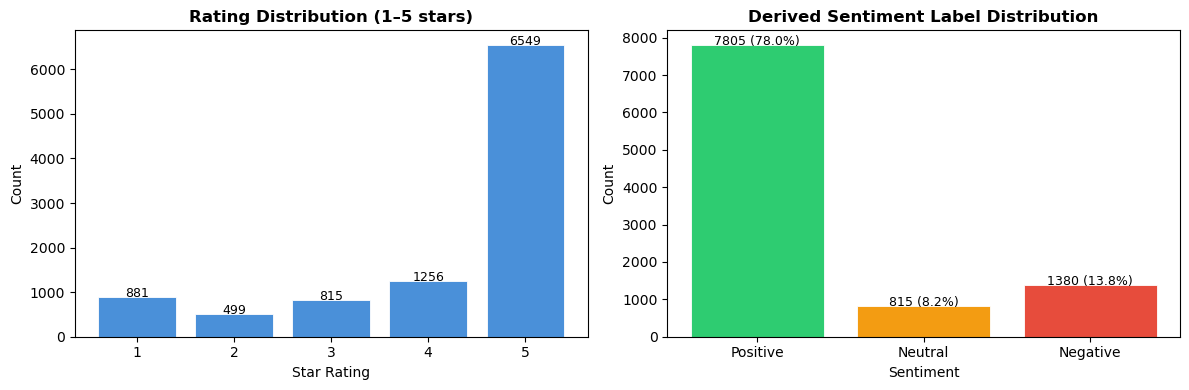

Figure A saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw star ratings
rating_counts = df["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(int),
            rating_counts.values,
            color="#4A90D9", edgecolor="white", linewidth=0.6)
axes[0].set_title("Rating Distribution (1–5 stars)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Star Rating"); axes[0].set_ylabel("Count")
for i, (x, y) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(x, y + 0.3, str(y), ha="center", fontsize=9)

# Derived 3-class sentiment labels
label_counts = df["sentiment_label"].value_counts().reindex(["Positive","Neutral","Negative"])
colours = ["#2ECC71", "#F39C12", "#E74C3C"]
axes[1].bar(label_counts.index, label_counts.values,
            color=colours, edgecolor="white", linewidth=0.6)
axes[1].set_title("Derived Sentiment Label Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Sentiment"); axes[1].set_ylabel("Count")
for x, y in zip(label_counts.index, label_counts.values):
    pct = y / len(df) * 100
    axes[1].text(x, y + 0.3, f"{y} ({pct:.1f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("data/fig_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure A saved.")


### 4.2 Review Length Distribution

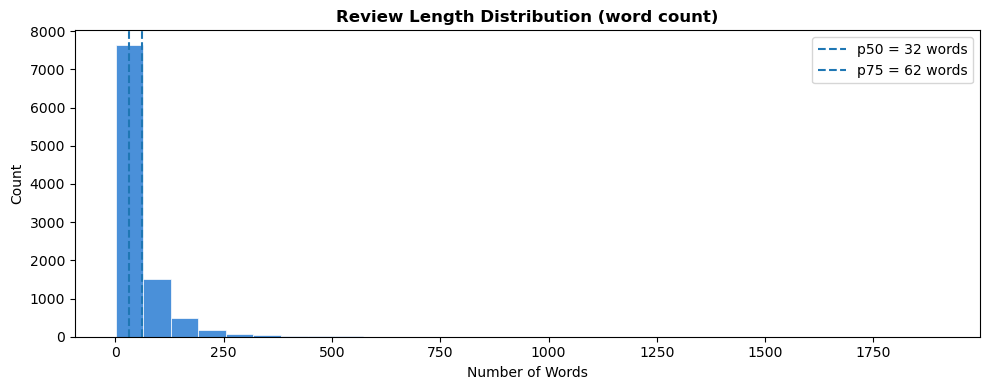

Median length : 32 words
Mean length   : 51.4 words
Max length    : 1901 words
Reviews < 10w : 1497 (15.0%)


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df["word_count"], bins=30, color="#4A90D9", edgecolor="white", linewidth=0.5)
for pct, val in [(50, df["word_count"].median()), (75, df["word_count"].quantile(0.75))]:
    ax.axvline(val, linestyle="--", linewidth=1.5,
               label=f"p{pct} = {val:.0f} words")
ax.set_title("Review Length Distribution (word count)", fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Words"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_review_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median length : {df['word_count'].median():.0f} words")
print(f"Mean length   : {df['word_count'].mean():.1f} words")
print(f"Max length    : {df['word_count'].max()} words")
print(f"Reviews < 10w : {(df['word_count'] < 10).sum()} ({(df['word_count'] < 10).mean()*100:.1f}%)")


### 4.3 Verified Purchase & Helpfulness by Sentiment

Verified purchase rate by sentiment:
sentiment_label
Positive    88.3%
Neutral     86.7%
Negative    90.9%
Name: verified_purchase, dtype: object

Mean helpful votes by sentiment:
sentiment_label
Positive    0.90
Neutral     0.84
Negative    1.29
Name: helpful_vote, dtype: float64


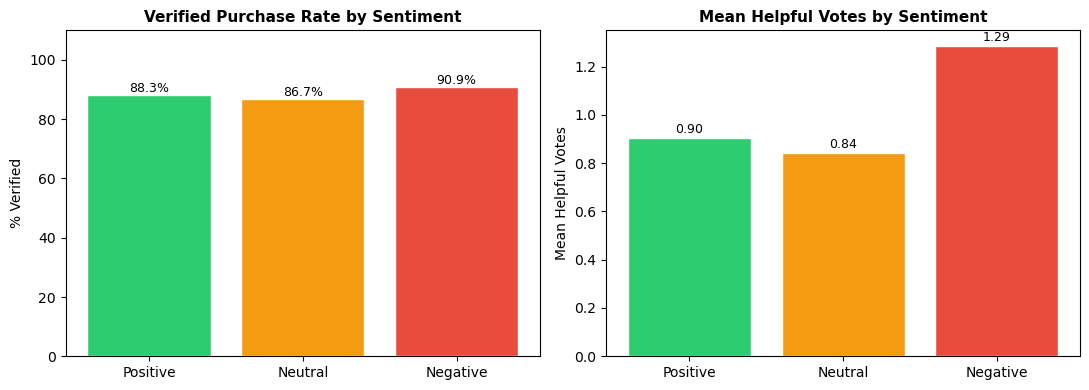

In [6]:
# Verified purchase rate per sentiment class
vp_rate = df.groupby("sentiment_label")["verified_purchase"].mean().reindex(
    ["Positive","Neutral","Negative"])
print("Verified purchase rate by sentiment:")
print(vp_rate.apply(lambda x: f"{x*100:.1f}%"))
print()

# Mean helpful votes per sentiment class
hv_mean = df.groupby("sentiment_label")["helpful_vote"].mean().reindex(
    ["Positive","Neutral","Negative"])
print("Mean helpful votes by sentiment:")
print(hv_mean.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colours = {"Positive": "#2ECC71", "Neutral": "#F39C12", "Negative": "#E74C3C"}
c = [colours[s] for s in vp_rate.index]

axes[0].bar(vp_rate.index, vp_rate.values * 100, color=c, edgecolor="white")
axes[0].set_title("Verified Purchase Rate by Sentiment", fontsize=11, fontweight="bold")
axes[0].set_ylabel("% Verified"); axes[0].set_ylim(0, 110)
for x, y in zip(vp_rate.index, vp_rate.values):
    axes[0].text(x, y*100 + 1, f"{y*100:.1f}%", ha="center", fontsize=9)

axes[1].bar(hv_mean.index, hv_mean.values, color=c, edgecolor="white")
axes[1].set_title("Mean Helpful Votes by Sentiment", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Mean Helpful Votes")
for x, y in zip(hv_mean.index, hv_mean.values):
    axes[1].text(x, y + 0.02, f"{y:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("data/fig_verified_helpful.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4 Class Imbalance Summary

In [7]:
print("=" * 45)
print("CLASS DISTRIBUTION SUMMARY")
print("=" * 45)
for label in ["Positive", "Neutral", "Negative"]:
    n = (df["sentiment_label"] == label).sum()
    print(f"  {label:10s}: {n:>6,}  ({n/len(df)*100:.1f}%)")
print(f"  {'Total':10s}: {len(df):>6,}")
print()
print("NOTE: Class imbalance present (positivity bias).")
print("Notebooks 02 and 03 apply class_weight='balanced'")
print("and report macro-averaged F1 to account for this.")


CLASS DISTRIBUTION SUMMARY
  Positive  :  7,805  (78.0%)
  Neutral   :    815  (8.2%)
  Negative  :  1,380  (13.8%)
  Total     : 10,000

NOTE: Class imbalance present (positivity bias).
Notebooks 02 and 03 apply class_weight='balanced'
and report macro-averaged F1 to account for this.


## 5. Summary
Cleaned data saved to `data/cleaned_reviews.csv`.  
Key observations for the report:
- Right-skewed rating distribution (positivity bias) mirrors the full 16M-row corpus
- Median review length ~31 words — short text that challenges bag-of-words models
- Negative reviews attract higher mean helpful votes, suggesting complaint signal utility
- Class imbalance requires balanced weighting and macro F1 as the primary metric